# Koo preds — quick visual QC

Loads `MoConsSwap_mpra/data/koo_attributions/joint_library_combined_koo_preds.csv`
(written by `load_full_library_preds.ipynb`) and plots:
1. predicted vs measured log2FC, per cell type
2. all pairwise pred-vs-pred scatters (same sequence, different cell type)

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

KOO_DIR = Path(
    "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/"
    "data/koo_attributions"
)
# results/ sits next to scripts/ (MoConsSwap_mpra/results)
RESULTS_DIR = Path(
    "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CELL_TYPES = ["HepG2", "K562", "WTC11"]

df = pd.read_csv(KOO_DIR / "joint_library_combined_koo_preds.csv")
print(df.shape)
df[[f"{ct}_pred_koo" for ct in CELL_TYPES]].describe()

(56978, 13)


,HepG2_pred_koo,K562_pred_koo,WTC11_pred_koo
count,56978.000000,56978.000000,56978.000000
mean,-0.400011,-0.194340,-0.918693
std,0.686638,0.370803,0.684424
min,-2.438209,-1.286746,-2.954958
25%,-0.864853,-0.423713,-1.317537
50%,-0.537643,-0.282727,-1.103582
75%,-0.060059,-0.063112,-0.763506
max,4.417459,2.228640,3.857864


wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results/koo_pred_vs_measured.png


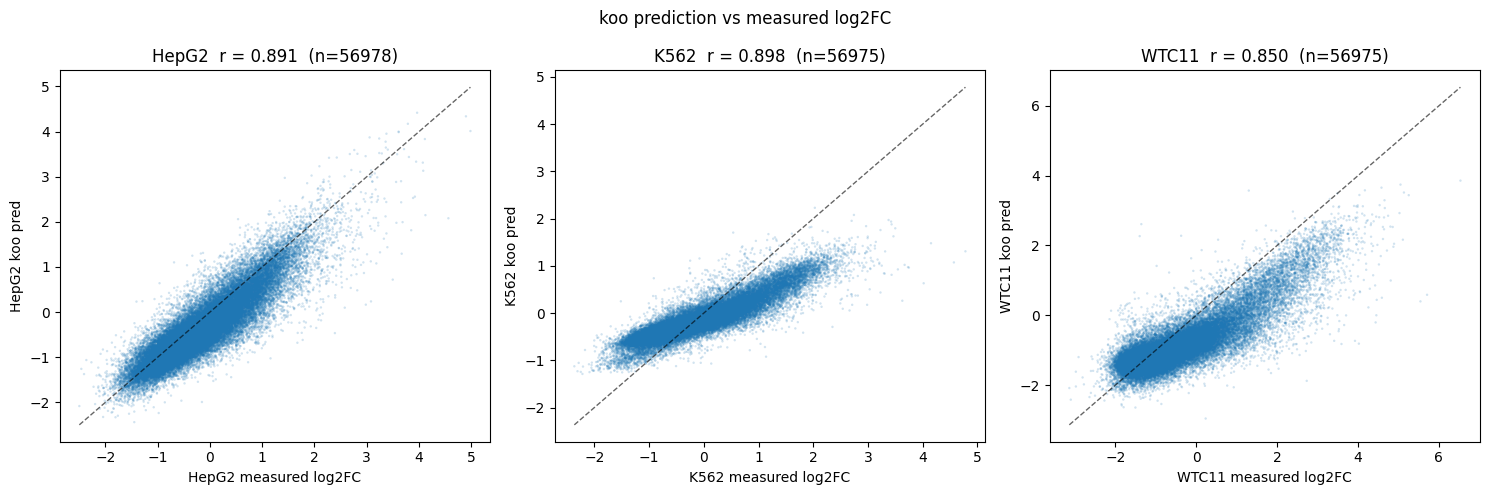

In [2]:
# Predicted vs measured log2FC, one panel per cell type.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ct in zip(axes, CELL_TYPES):
    x = df[f"{ct}_log2FC"]
    y = df[f"{ct}_pred_koo"]
    m = x.notna() & y.notna()
    r, _ = pearsonr(x[m], y[m])
    ax.scatter(x[m], y[m], s=3, alpha=0.2, edgecolors="none")
    lo = min(x[m].min(), y[m].min())
    hi = max(x[m].max(), y[m].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
    ax.set_xlabel(f"{ct} measured log2FC")
    ax.set_ylabel(f"{ct} koo pred")
    ax.set_title(f"{ct}  r = {r:.3f}  (n={m.sum()})")
fig.suptitle("koo prediction vs measured log2FC")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "koo_pred_vs_measured.png", dpi=150, bbox_inches="tight")
print("wrote", RESULTS_DIR / "koo_pred_vs_measured.png")
plt.show()

wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results/koo_pred_pairwise.png


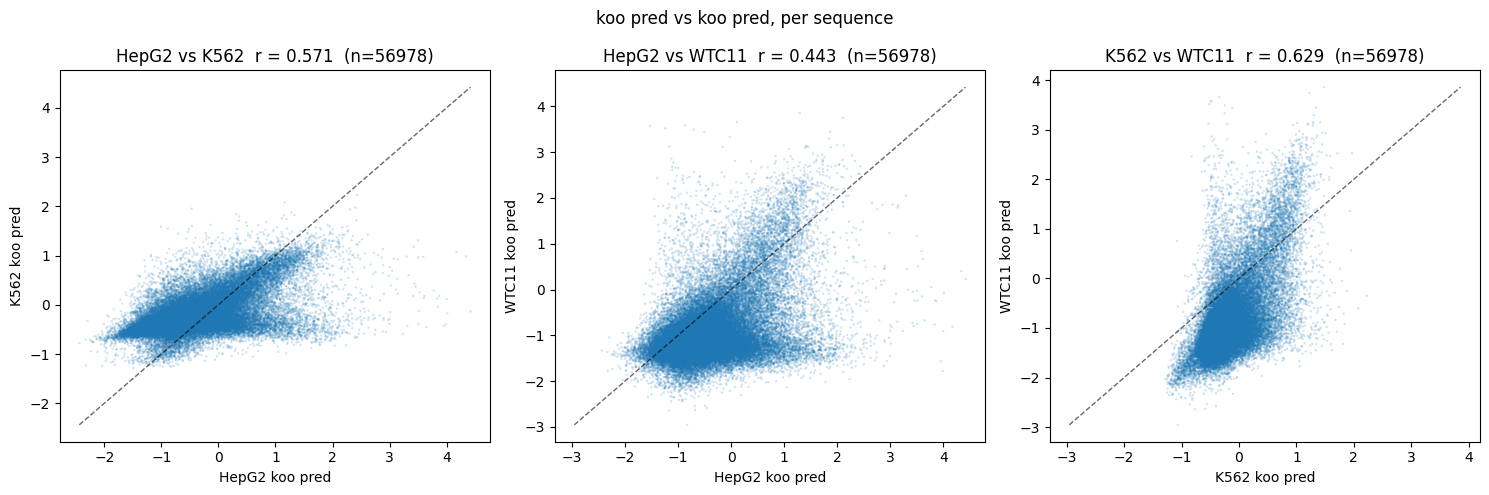

In [3]:
# Pairwise pred-vs-pred (same sequence, different cell type).
pairs = list(combinations(CELL_TYPES, 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 5))
for ax, (a, b) in zip(axes, pairs):
    x = df[f"{a}_pred_koo"]
    y = df[f"{b}_pred_koo"]
    m = x.notna() & y.notna()
    r, _ = pearsonr(x[m], y[m])
    ax.scatter(x[m], y[m], s=3, alpha=0.2, edgecolors="none")
    lo = min(x[m].min(), y[m].min())
    hi = max(x[m].max(), y[m].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
    ax.set_xlabel(f"{a} koo pred")
    ax.set_ylabel(f"{b} koo pred")
    ax.set_title(f"{a} vs {b}  r = {r:.3f}  (n={m.sum()})")
fig.suptitle("koo pred vs koo pred, per sequence")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "koo_pred_pairwise.png", dpi=150, bbox_inches="tight")
print("wrote", RESULTS_DIR / "koo_pred_pairwise.png")
plt.show()

wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results/koo_pred_corr_heatmap.png


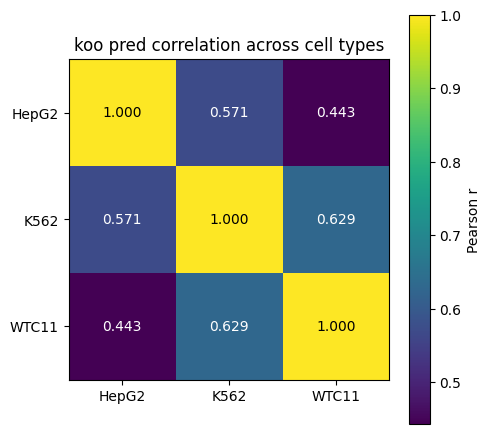

In [4]:
# 3x3 correlation heatmap of the koo preds across cell types.
pred_cols = [f"{ct}_pred_koo" for ct in CELL_TYPES]
corr = df[pred_cols].corr()  # Pearson

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr.values, cmap="viridis", vmin=corr.values.min(), vmax=1.0)
ax.set_xticks(range(len(CELL_TYPES)), CELL_TYPES)
ax.set_yticks(range(len(CELL_TYPES)), CELL_TYPES)
for i in range(len(CELL_TYPES)):
    for j in range(len(CELL_TYPES)):
        ax.text(j, i, f"{corr.values[i, j]:.3f}", ha="center", va="center",
                color="white" if corr.values[i, j] < 0.8 else "black")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("koo pred correlation across cell types")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "koo_pred_corr_heatmap.png", dpi=150, bbox_inches="tight")
print("wrote", RESULTS_DIR / "koo_pred_corr_heatmap.png")
plt.show()

wrote /grid/koo/home/pmantill/projects/Virtual_Experiments/MoConsSwap_mpra/results/koo_pred_dist_tertiles.png
equal-count tertile boundaries (low, high) per cell type:
  HepG2: (-0.7544, -0.2621)
  K562: (-0.3757, -0.1610)
  WTC11: (-1.2455, -0.9127)


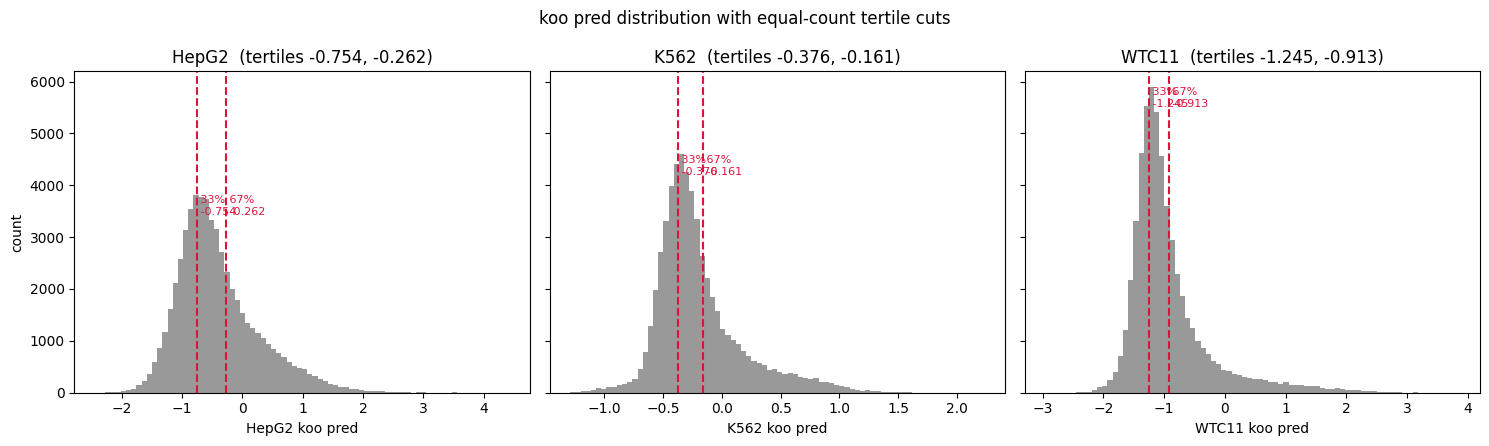

In [8]:
# Distribution of koo preds per cell type, with equal-count tertile cuts marked.
# The 33.3 / 66.7 percentiles are the boundaries that give 3 equal-size bins;
# use the printed values as a starting point for the manual bins below.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
tertiles = {}
for ax, ct in zip(axes, CELL_TYPES):
    v = df[f"{ct}_pred_koo"].dropna().values
    lo, hi = np.quantile(v, [1 / 3, 2 / 3])
    tertiles[ct] = (float(lo), float(hi))
    ax.hist(v, bins=80, color="0.6", edgecolor="none")
    for b, lab in [(lo, "33%"), (hi, "67%")]:
        ax.axvline(b, color="crimson", lw=1.5, ls="--")
        ax.text(b, ax.get_ylim()[1] * 0.95, f" {lab}\n {b:.3f}",
                color="crimson", fontsize=8, va="top")
    ax.set_xlabel(f"{ct} koo pred")
    ax.set_title(f"{ct}  (tertiles {lo:.3f}, {hi:.3f})")
axes[0].set_ylabel("count")
fig.suptitle("koo pred distribution with equal-count tertile cuts")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "koo_pred_dist_tertiles.png", dpi=150, bbox_inches="tight")
print("wrote", RESULTS_DIR / "koo_pred_dist_tertiles.png")
print("equal-count tertile boundaries (low, high) per cell type:")
for ct, (lo, hi) in tertiles.items():
    print(f"  {ct}: ({lo:.4f}, {hi:.4f})")
plt.show()

In [14]:
# Equal-size activity bins: take exactly N_BIN seqs in each of repressing /
# neutral / activating per cell type. These bins do NOT cover the full library
# (repressing = lowest N_BIN preds, activating = highest N_BIN, neutral = N_BIN
# centered on the median); everything else is left unbinned.
# =====================================================================
N_BIN = 300           # seqs per bin (you'll randomly draw 100 of these later)
# =====================================================================

LABELS = ["repressing", "neutral", "activating"]
BOUNDS = {}
for ct in CELL_TYPES:
    s = df[f"{ct}_pred_koo"]
    v = s.dropna()
    n = len(v)
    f = N_BIN / n
    # 4 edges from quantiles: [rep | ... | neutral | ... | act]
    rep_hi = v.quantile(f)
    neu_lo = v.quantile(0.5 - f / 2)
    neu_hi = v.quantile(0.5 + f / 2)
    act_lo = v.quantile(1 - f)
    BOUNDS[ct] = dict(rep_hi=float(rep_hi), neu_lo=float(neu_lo),
                      neu_hi=float(neu_hi), act_lo=float(act_lo))

    cat = pd.Series(pd.NA, index=df.index, dtype="object")
    cat[s < rep_hi] = "repressing"
    cat[(s >= neu_lo) & (s < neu_hi)] = "neutral"
    cat[s >= act_lo] = "activating"
    df[f"{ct}_actbin"] = pd.Categorical(cat, categories=LABELS)

    counts = df[f"{ct}_actbin"].value_counts().reindex(LABELS)
    print(f"{ct}: rep<{rep_hi:.4f}  neu[{neu_lo:.4f},{neu_hi:.4f})  "
          f"act>={act_lo:.4f}")
    print("   " + "  ".join(f"{b}={counts[b]}" for b in LABELS)
          + f"  (unbinned={df[f'{ct}_actbin'].isna().sum()})")

HepG2: rep<-1.6873  neu[-0.5416,-0.5336)  act>=1.9204
   repressing=300  neutral=300  activating=300  (unbinned=56078)
K562: rep<-0.9788  neu[-0.2843,-0.2811)  act>=1.1190
   repressing=300  neutral=300  activating=300  (unbinned=56078)
WTC11: rep<-1.9610  neu[-1.1061,-1.1016)  act>=2.1062
   repressing=300  neutral=300  activating=300  (unbinned=56078)


In [15]:
# Build a pred-stratified sub-library per cell type by randomly sampling
# sequences from the bins you choose (the bins do NOT cover the full library —
# this is a deliberate subsample).
# =====================================================================
# EDIT THESE:
PICK_BINS   = ["repressing", "neutral", "activating"]  # which bins to draw from
N_PER_BIN   = 100           # sequences sampled per bin per cell type
SEED        = 0             # reproducible RNG
STRAT_DIR   = Path("/grid/koo/home/pmantill/projects/Virtual_Experiments/"
                    "MoConsSwap_mpra/data/stratified_libs")
# =====================================================================
STRAT_DIR.mkdir(parents=True, exist_ok=True)

strat = {}
for ct in CELL_TYPES:
    parts = []
    for lab in PICK_BINS:
        pool = df[df[f"{ct}_actbin"] == lab]
        take = min(N_PER_BIN, len(pool))
        if take < N_PER_BIN:
            print(f"  ! {ct}/{lab}: only {len(pool)} avail, taking {take}")
        parts.append(pool.sample(n=take, random_state=SEED))
    sub = (pd.concat(parts)
             .sample(frac=1, random_state=SEED)   # shuffle bin order
             .reset_index(drop=True))
    strat[ct] = sub
    out = STRAT_DIR / f"{ct}_pred_stratified_lib.csv"
    sub.to_csv(out, index=False)
    n_by = sub[f"{ct}_actbin"].value_counts().reindex(PICK_BINS)
    print(f"{ct}: {len(sub)} seqs -> {out.name}  "
          + "  ".join(f"{b}={n_by[b]}" for b in PICK_BINS))

HepG2: 300 seqs -> HepG2_pred_stratified_lib.csv  repressing=100  neutral=100  activating=100
K562: 300 seqs -> K562_pred_stratified_lib.csv  repressing=100  neutral=100  activating=100
WTC11: 300 seqs -> WTC11_pred_stratified_lib.csv  repressing=100  neutral=100  activating=100
